In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Chargement
df = pd.read_csv("../data/raw/bank_credit_dataset.csv")

# Aperçu
df.head()

,Age,Income,CreditScore,LoanAmount,LoanDuration,ExistingLoans,Balance,JobType,MaritalStatus,HomeOwner,Default
0,59,8712.762116,649.224107,16548.712928,36,1,9323.864683,self-employed,married,1,1
1,49,37196.956047,729.331773,6943.201865,48,0,6553.595474,employee,married,1,0
2,35,36416.307370,621.240098,20380.774958,24,2,-3104.676986,unemployed,single,1,0
3,63,61452.334548,745.448294,20523.847164,36,1,4240.545231,manager,single,1,0
4,28,45005.917953,638.777357,31037.750222,36,2,12870.622489,manager,divorced,1,0


1. Analyse de la variable cible


In [3]:
df["Default"].value_counts()

Default
0    4263
1     737
Name: count, dtype: int64

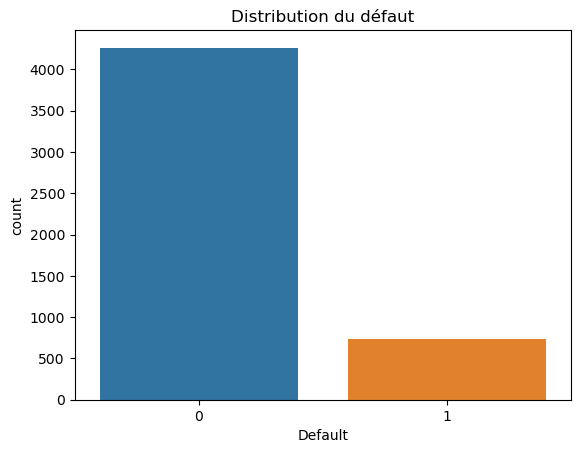

In [4]:
sns.countplot(x="Default", data=df)
plt.title("Distribution du défaut")
plt.show()

La variable cible est déséquilibrée, avec environ 85 % des clients qui remboursent leur crédit contre seulement 15 % en défaut.
Ce déséquilibre peut entraîner un biais des modèles vers la classe majoritaire. Il est donc nécessaire d’utiliser des métriques adaptées telles que le recall, le F1-score ou la ROC-AUC.

2. Distribution des variables

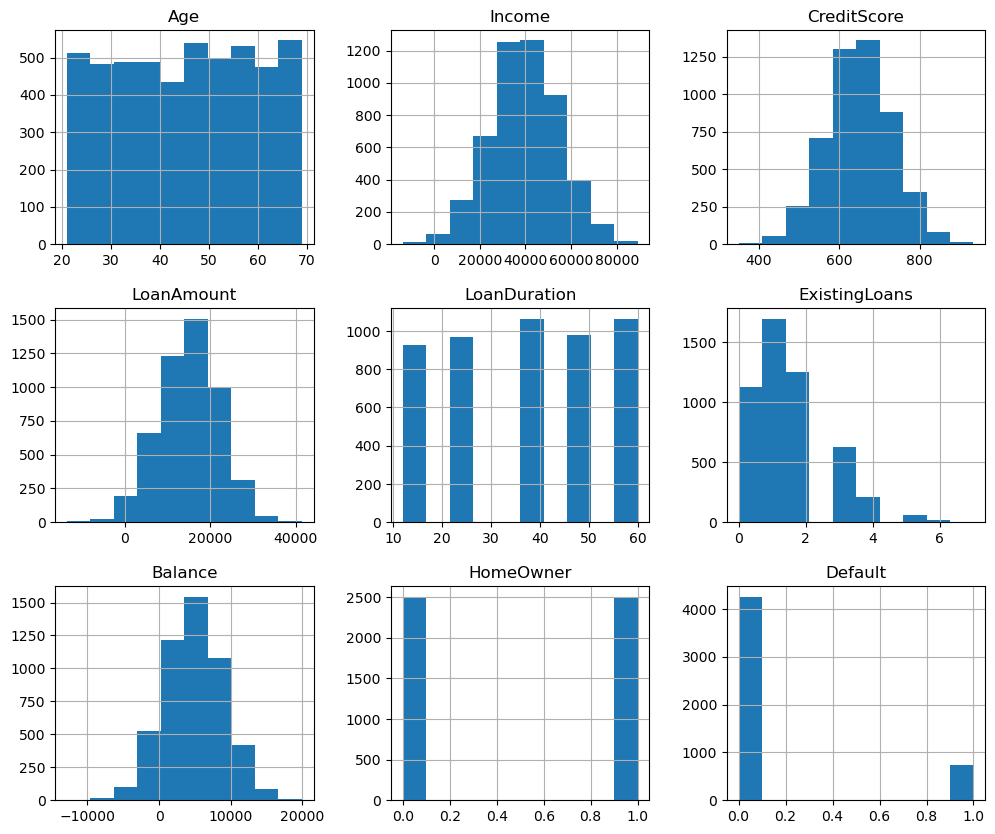

In [5]:
df.hist(figsize=(12,10))
plt.show()

INTERPRÉTATION

Les variables numériques présentent des distributions globalement réalistes.
L’âge est réparti de manière uniforme, tandis que les revenus et les montants de prêt présentent une dispersion importante, traduisant une diversité de profils clients.
Cette variabilité est importante pour entraîner des modèles robustes.

3. Matrice de corrélation

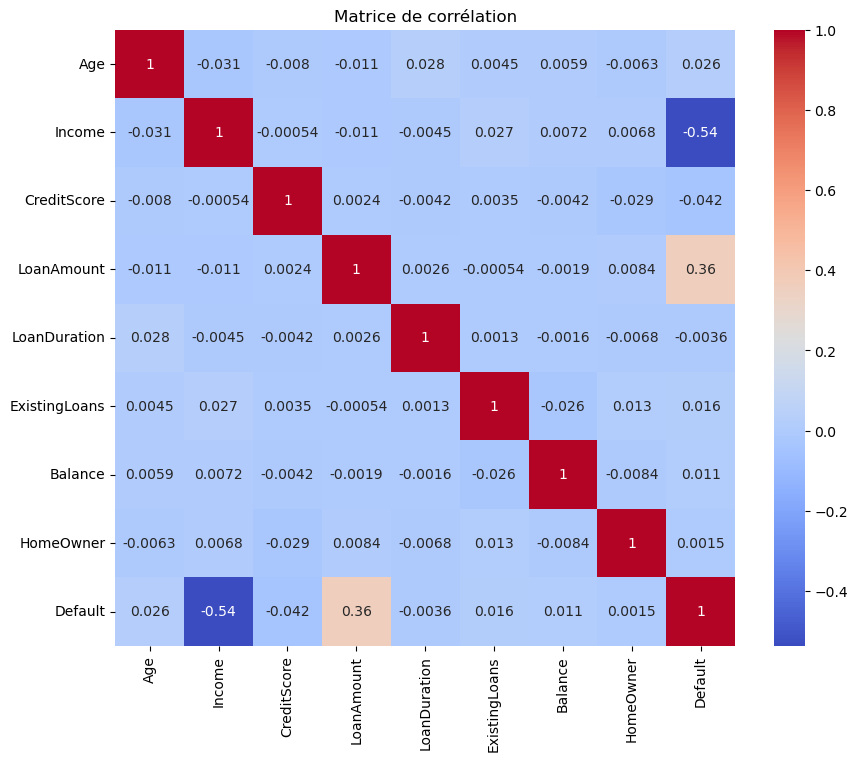

In [6]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Matrice de corrélation")
plt.show()

INTERPRÉTATION

L’analyse de la matrice de corrélation montre que :

- Le montant du prêt (LoanAmount) est positivement corrélé au défaut
- Le nombre de crédits existants (ExistingLoans) augmente également le risque
- Le score de crédit (CreditScore) est négativement corrélé au défaut
- Le revenu (Income) est également négativement corrélé


Ces résultats sont cohérents avec la logique métier bancaire :
les clients ayant des revenus élevés et un bon score de crédit présentent un risque plus faible, tandis que les clients fortement endettés ou ayant plusieurs crédits en cours sont plus susceptibles de faire défaut.


4. Analyse par classe


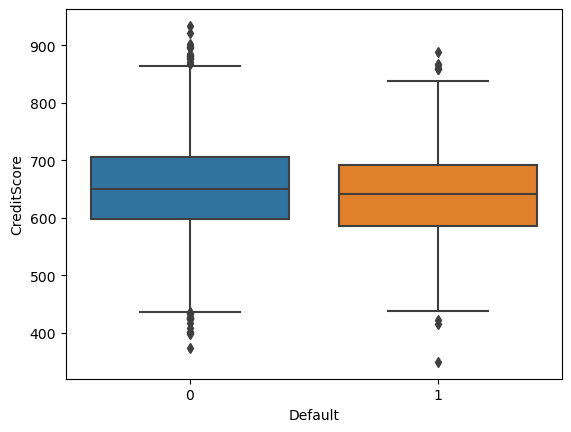

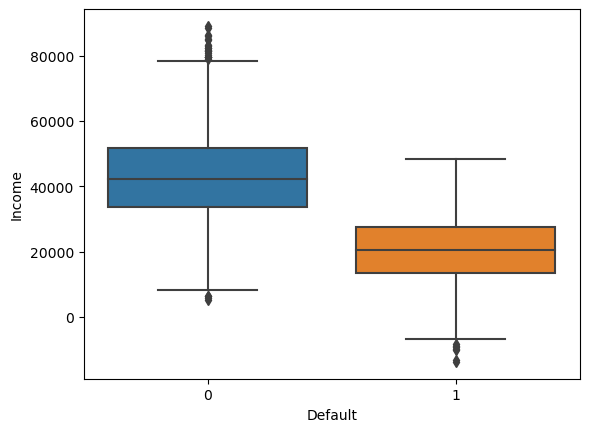

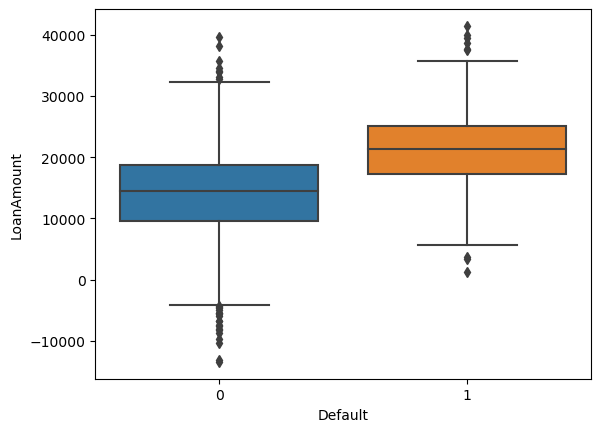

In [7]:
sns.boxplot(x="Default", y="CreditScore", data=df)
plt.show()

sns.boxplot(x="Default", y="Income", data=df)
plt.show()

sns.boxplot(x="Default", y="LoanAmount", data=df)
plt.show()


INTERPRÉTATION

- CreditScore

Les clients en défaut présentent un score de crédit significativement plus faible, ce qui confirme que le score de crédit est un indicateur clé du risque.

- Income

Les clients en défaut ont en moyenne des revenus plus faibles, ce qui limite leur capacité de remboursement.

- LoanAmount

Les clients en défaut ont tendance à contracter des prêts plus élevés, augmentant leur niveau de risque.


5. Variables catégorielles

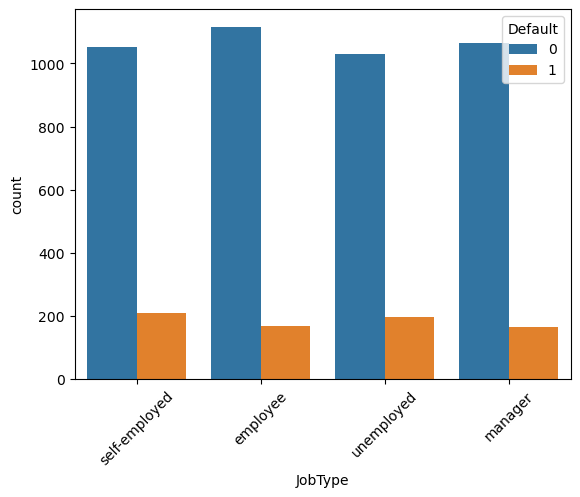

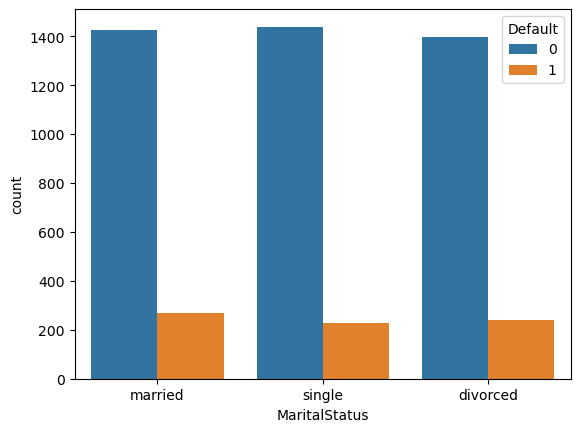

In [8]:
sns.countplot(x="JobType", hue="Default", data=df)
plt.xticks(rotation=45)
plt.show()

sns.countplot(x="MaritalStatus", hue="Default", data=df)
plt.show()

INTERPRÉTATION

- JobType

Certaines catégories professionnelles, notamment les personnes sans emploi ou indépendantes, semblent présenter un risque plus élevé.

- MaritalStatus

Le statut marital peut influencer le risque, bien que son impact soit moins marqué que les variables financières.

 

In [9]:
df.groupby("Default").mean(numeric_only=True)

,Age,Income,CreditScore,LoanAmount,LoanDuration,ExistingLoans,Balance,HomeOwner
Default,,,,,,,,
0,45.077176,43070.110664,650.410452,14078.608660,36.723434,1.469388,4881.095941,0.501290
1,46.130258,20143.412974,640.949404,21294.038813,36.553596,1.525102,5012.663575,0.503392


INTERPRÉTATION

Les moyennes confirment les tendances observées :

- les clients en défaut ont un revenu plus faible
- un score de crédit plus bas
- un montant de prêt plus élevé
- davantage de crédits en cours


CONCLUSION EDA


L’analyse exploratoire des données a permis d’identifier les variables les plus influentes dans la prédiction du défaut de crédit.
Les variables financières telles que le revenu, le score de crédit, le montant du prêt et le nombre de crédits existants jouent un rôle déterminant.
Ces observations guideront les étapes suivantes de modélisation et de sélection des variables.
